# Regularization: Ridge (L2) and Lasso (L1)

Regularization is one of the most powerful ideas in machine learning. Without it, expressive models tend to **overfit**: they memorize the noise in training data instead of learning the true signal.

This notebook covers, from first principles:
1. **The overfitting problem** — why we need regularization
2. **Ridge Regression (L2)** — shrinks all weights smoothly toward zero
3. **Lasso Regression (L1)** — shrinks weights *and* can zero them out entirely
4. **Regularization paths** — how weights evolve as the penalty grows
5. **Interactive exploration** and a **side-by-side comparison**


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, FloatLogSlider
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})


---
## 1 · The Overfitting Problem

### Why do models overfit?

Consider fitting a polynomial of degree $d$ to $n$ training points. When $d$ is large, the model has enough parameters to pass *exactly* through every training point — but the result looks nothing like the true function.

**Analogy:** Imagine trying to summarize 30 students' exam scores with a single trend. A straight line might not be perfect, but it captures the pattern. A squiggly curve that passes through every dot "fits" the data perfectly — but it would make terrible predictions for new students, because it memorized noise instead of the trend. That's overfitting.

---

### The loss function we're minimizing

The goal of OLS is to minimize the **mean squared error (MSE)** between predictions and true values:

$$\mathcal{L}_{OLS}(\mathbf{w}) = \frac{1}{n}\|\mathbf{y} - X\mathbf{w}\|_2^2$$

**Breaking this down piece by piece:**

1. $X\mathbf{w}$ = our predictions $\hat{\mathbf{y}}$. We multiply our features by our weights to get a predicted value for each sample.
2. $\mathbf{y} - X\mathbf{w}$ = the **residuals** — how wrong we are for each sample (positive if we underestimated, negative if we overestimated).
3. $\|\cdot\|_2^2$ means "square every residual, then sum them all up":

$$\|\mathbf{y} - X\mathbf{w}\|_2^2 = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

4. Dividing by $n$ gives us the **average** squared error across all samples.

The notation table below gives each symbol a concrete meaning:

| Symbol | Meaning |
|--------|---------|
| $X \in \mathbb{R}^{n \times p}$ | Feature matrix — think of it as a spreadsheet with $n$ rows (samples) and $p$ columns (features) |
| $\mathbf{y} \in \mathbb{R}^n$ | Target values — the correct answers we're trying to predict |
| $\mathbf{w} \in \mathbb{R}^p$ | Weight vector — the $p$ numbers we're learning (one per feature) |
| $\hat{\mathbf{y}} = X\mathbf{w}$ | Predictions — what our model guesses |
| $\mathcal{L}$ | Loss — a single number measuring "how wrong are we on average right now?" |

---

### The core problem

OLS has **no mechanism to prefer small weights**. If using a huge weight on a feature reduces training error, it will use it — even if that causes the curve to swing wildly on unseen data.

> **Key insight:** Overfitting happens because OLS only cares about training error. Regularization adds a *penalty on weight magnitude* to the loss, forcing the model to trade a little accuracy for a lot of simplicity.
>
> **Analogy:** Think of it like a tax on complexity. You *can* use a large weight, but you'll pay extra for it in the loss. The model learns to only use big weights when they genuinely earn their keep.


---
## 2 · Dataset

We use a classic overfitting demo: fit a **degree-12 polynomial** to 30 noisy samples from $y = \sin(x)$.

The true signal is smooth. With 12 polynomial features but only 30 points, OLS can produce a wildly oscillating fit. Regularization tames it.


In [19]:
def make_poly_features(x, degree):
    """Return matrix of shape (len(x), degree) with columns [x, x^2, ..., x^degree]."""
    return np.column_stack([x**i for i in range(1, degree + 1)])

def true_func(x):
    return np.sin(x)

# Training data: 30 noisy samples
N_TRAIN = 30
DEGREE  = 12

x_train = np.sort(np.random.uniform(-3, 3, N_TRAIN))
y_train = true_func(x_train) + np.random.normal(0, 0.25, N_TRAIN)

# Dense grid for evaluation / plotting
x_test  = np.linspace(-3.2, 3.2, 400)
y_true  = true_func(x_test)

# Raw polynomial feature matrices
X_train_raw = make_poly_features(x_train, DEGREE)
X_test_raw  = make_poly_features(x_test,  DEGREE)

# Standardise features (zero mean, unit variance on training set)
# This is CRITICAL before applying regularization so the penalty
# treats each feature on equal footing.
X_mean = X_train_raw.mean(axis=0)
X_std  = X_train_raw.std(axis=0) + 1e-8

X_train = (X_train_raw - X_mean) / X_std
X_test  = (X_test_raw  - X_mean) / X_std

print(f"Training samples : {N_TRAIN}")
print(f"Polynomial degree: {DEGREE}  →  {DEGREE} features")
print(f"X_train shape    : {X_train.shape}")


Training samples : 30
Polynomial degree: 12  →  12 features
X_train shape    : (30, 12)


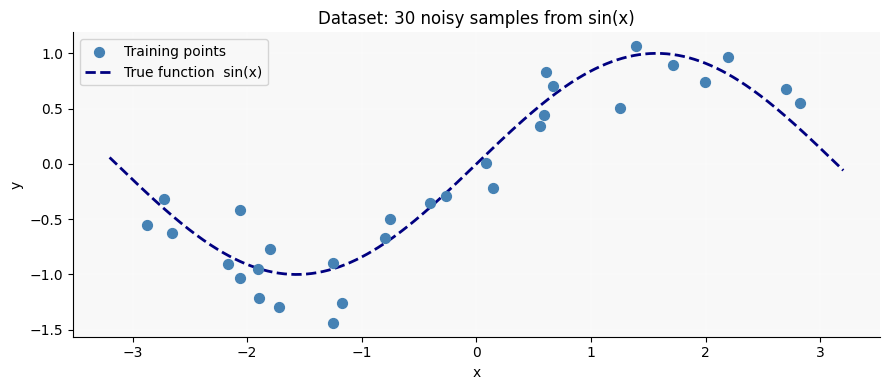

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, label="Training points")
ax.plot(x_test, y_true, color="navy", lw=2, ls="--", label="True function  sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dataset: 30 noisy samples from sin(x)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3 · Ordinary Least Squares (Baseline)

### How do we solve for the best weights?

We want to find the weight vector $\mathbf{w}$ that makes the loss as small as possible. The calculus trick: at the minimum of any smooth function, its **slope (gradient) is zero**. So we differentiate the loss with respect to $\mathbf{w}$ and set it to zero.

**Step 1 — Compute the gradient** (how the loss changes when we nudge each weight):

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = -\frac{2}{n}X^T(\mathbf{y} - X\mathbf{w})$$

*In plain English:* $X^T(\mathbf{y} - X\mathbf{w})$ is "how correlated is each feature with the current residuals?" If feature $j$ is highly correlated with our current errors, its weight should move in that direction.

**Step 2 — Set the gradient to zero** and rearrange:

$$-\frac{2}{n}X^T(\mathbf{y} - X\mathbf{w}) = \mathbf{0}$$

$$X^T\mathbf{y} - X^TX\mathbf{w} = \mathbf{0}$$

$$X^TX\mathbf{w} = X^T\mathbf{y}$$

**Step 3 — Solve for $\mathbf{w}$** by multiplying both sides by the inverse of $X^TX$:

$$\boxed{\mathbf{w}^* = (X^TX)^{-1}X^T\mathbf{y}}$$

This is the **Normal Equation** — a direct formula for the best weights.

**Intuition for $(X^TX)^{-1}X^T$:** This is sometimes called the "pseudo-inverse" of $X$. It's the matrix that "undoes" $X$ in a least-squares sense — like dividing both sides by $X$ if $X$ were just a number.

> **What can go wrong?** The matrix $X^TX$ must be invertible. With 12 polynomial features and only 30 training points, OLS can still technically find a solution — but the weights end up massive in magnitude. The code below shows this: look at how some OLS weights are in the hundreds!


In [21]:
def fit_ols(X, y):
    """OLS via the normal equation. Returns weight vector w."""
    return np.linalg.lstsq(X, y, rcond=None)[0]

w_ols = fit_ols(X_train, y_train)
y_pred_ols = X_test @ w_ols

train_mse_ols = np.mean((X_train @ w_ols - y_train) ** 2)
test_mse_ols  = np.mean((y_pred_ols - y_true) ** 2)

print("OLS weights (rounded):")
for i, wi in enumerate(w_ols, 1):
    print(f"  w_{i:2d} (degree {i:2d}) = {wi:+.4f}")
print(f"\nTrain MSE : {train_mse_ols:.4f}")
print(f"Test  MSE : {test_mse_ols:.4f}   ← should be much larger")


OLS weights (rounded):
  w_ 1 (degree  1) = +1.1275
  w_ 2 (degree  2) = +3.1600
  w_ 3 (degree  3) = +4.9903
  w_ 4 (degree  4) = -36.5321
  w_ 5 (degree  5) = -28.0448
  w_ 6 (degree  6) = +148.0117
  w_ 7 (degree  7) = +55.1532
  w_ 8 (degree  8) = -270.7904
  w_ 9 (degree  9) = -48.0991
  w_10 (degree 10) = +229.5731
  w_11 (degree 11) = +15.4737
  w_12 (degree 12) = -73.4609

Train MSE : 0.0708
Test  MSE : 8.4746   ← should be much larger


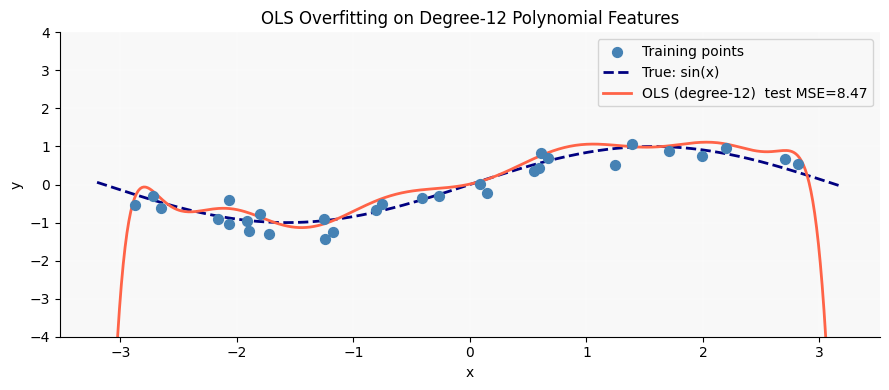

Notice: OLS follows training points almost perfectly yet diverges wildly elsewhere.


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, label="Training points")
ax.plot(x_test, y_true,    color="navy",    lw=2, ls="--", label="True: sin(x)")
ax.plot(x_test, y_pred_ols, color="tomato", lw=2,          label=f"OLS (degree-12)  test MSE={test_mse_ols:.2f}")
ax.set_ylim(-4, 4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("OLS Overfitting on Degree-12 Polynomial Features")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Notice: OLS follows training points almost perfectly yet diverges wildly elsewhere.")


---
## 4 · Ridge Regression (L2 Regularization)

### The core idea in one sentence

Ridge takes the OLS loss and adds a penalty that grows whenever any weight gets large — forcing the model to keep its weights small and well-behaved.

### The loss function

$$\mathcal{L}_{Ridge}(\mathbf{w}) = \underbrace{\frac{1}{n}\|\mathbf{y} - X\mathbf{w}\|_2^2}_{\text{fit the data}} + \underbrace{\lambda\|\mathbf{w}\|_2^2}_{\text{penalty for large weights}}$$

**Breaking down the penalty term $\lambda\|\mathbf{w}\|_2^2$:**

- $\|\mathbf{w}\|_2^2 = w_1^2 + w_2^2 + \cdots + w_p^2$ — it's just the sum of squared weights.
- Multiplying by $\lambda$ scales how severely we punish large weights.
- Every time we reduce a weight, the penalty shrinks — so the model is always "incentivized" to make weights smaller.

**Analogy:** Imagine you're packing a suitcase and each item has a weight limit fee. OLS packs whatever fits best without caring about fees. Ridge always considers the fee — it won't pack a heavy item unless it genuinely needs it.

The scalar $\lambda \geq 0$ is the **regularization strength** — your dial between "care only about fit" and "care only about small weights":
- $\lambda = 0$: no penalty → identical to OLS
- $\lambda \to \infty$: penalty dominates → all weights shrink toward zero (underfitting)
- Somewhere in between → the sweet spot

---

### Closed-form derivation (step by step)

Just like OLS, we differentiate and set the gradient to zero. The only difference is the penalty term adds an extra piece to the gradient.

**Step 1 — The gradient** of the Ridge loss:

$$\frac{\partial \mathcal{L}_{Ridge}}{\partial \mathbf{w}} = \underbrace{-\frac{2}{n}X^T(\mathbf{y} - X\mathbf{w})}_{\text{same as OLS gradient}} + \underbrace{2\lambda\mathbf{w}}_{\text{new: penalty gradient}}$$

*The penalty gradient $2\lambda\mathbf{w}$ always points back toward zero — it's a constant force pulling each weight toward the origin.*

**Step 2 — Set to zero** and rearrange:

$$\frac{2}{n}X^TX\mathbf{w} + 2\lambda\mathbf{w} = \frac{2}{n}X^T\mathbf{y}$$

Factor out $\mathbf{w}$ on the left (treating $\mathbf{w}$ like multiplying by a shared matrix):

$$\left(\frac{1}{n}X^TX + \lambda I\right)\mathbf{w} = \frac{1}{n}X^T\mathbf{y}$$

**Step 3 — Solve** (multiply both sides by the inverse):

$$\boxed{\mathbf{w}^*_{Ridge} = (X^TX + \lambda n I)^{-1}X^T\mathbf{y}}$$

*Compare to OLS: $(X^TX)^{-1}X^T\mathbf{y}$. Ridge just adds $\lambda n$ to the diagonal before inverting. That small diagonal bump is what tames the large weights.*

> **Bonus:** Adding $\lambda n I$ makes the matrix $(X^TX + \lambda n I)$ always invertible, even when features are nearly identical or there are more features than samples. OLS can break in those cases; Ridge never does.

---

### Gradient descent view

If we want to train Ridge iteratively (useful for very large datasets where the closed form is too slow), the update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha\left[\frac{2}{n}X^T(X\mathbf{w} - \mathbf{y}) + 2\lambda\mathbf{w}\right]$$

**In plain English:** Each step moves weights in the direction that reduces prediction error *and* simultaneously shrinks them a little toward zero (the $2\lambda\mathbf{w}$ term).

> **Key insight:** Ridge can be thought of as saying "I believe the true weights are drawn from a bell-shaped distribution centered at zero — so unless the data strongly disagrees, keep them near zero." Large weights are possible but require strong evidence from the data.


In [23]:
def fit_ridge_closed(X, y, lam):
    """Ridge closed-form: w = (X'X + lam*n*I)^{-1} X'y"""
    n, p = X.shape
    I = np.eye(p)
    return np.linalg.solve(X.T @ X + lam * n * I, X.T @ y)

def fit_ridge_gd(X, y, lam, lr=0.05, n_iter=2000):
    """Ridge via gradient descent. Returns (w, loss_history)."""
    n, p = X.shape
    w = np.zeros(p)
    loss_history = []

    for _ in range(n_iter):
        residual = X @ w - y                                    # shape (n,)
        mse  = (residual ** 2).mean()
        loss = mse + lam * (w ** 2).sum()
        loss_history.append(loss)

        grad = (2 / n) * X.T @ residual + 2 * lam * w          # shape (p,)
        w   -= lr * grad

    return w, loss_history


In [24]:
LAMBDA_RIDGE = 0.01   # regularization strength

w_ridge_cf, _  = fit_ridge_closed(X_train, y_train, LAMBDA_RIDGE), None
w_ridge_cf     = fit_ridge_closed(X_train, y_train, LAMBDA_RIDGE)
w_ridge_gd, loss_history_ridge = fit_ridge_gd(X_train, y_train, LAMBDA_RIDGE)

y_pred_ridge = X_test @ w_ridge_cf

train_mse_ridge = np.mean((X_train @ w_ridge_cf - y_train) ** 2)
test_mse_ridge  = np.mean((y_pred_ridge - y_true) ** 2)

print(f"Lambda (Ridge) = {LAMBDA_RIDGE}")
print(f"\nRidge weights (rounded):")
for i, wi in enumerate(w_ridge_cf, 1):
    print(f"  w_{i:2d} (degree {i:2d}) = {wi:+.4f}")
print(f"\nTrain MSE : {train_mse_ridge:.4f}")
print(f"Test  MSE : {test_mse_ridge:.4f}")
print(f"\nClosed-form vs GD max diff: {np.max(np.abs(w_ridge_cf - w_ridge_gd)):.6f}")


Lambda (Ridge) = 0.01

Ridge weights (rounded):
  w_ 1 (degree  1) = +1.2602
  w_ 2 (degree  2) = -0.1040
  w_ 3 (degree  3) = -0.4518
  w_ 4 (degree  4) = +0.2081
  w_ 5 (degree  5) = -0.3668
  w_ 6 (degree  6) = +0.1272
  w_ 7 (degree  7) = -0.1057
  w_ 8 (degree  8) = +0.0057
  w_ 9 (degree  9) = +0.0710
  w_10 (degree 10) = -0.0765
  w_11 (degree 11) = +0.1670
  w_12 (degree 12) = -0.1249

Train MSE : 0.0875
Test  MSE : 0.0919

Closed-form vs GD max diff: 0.012017


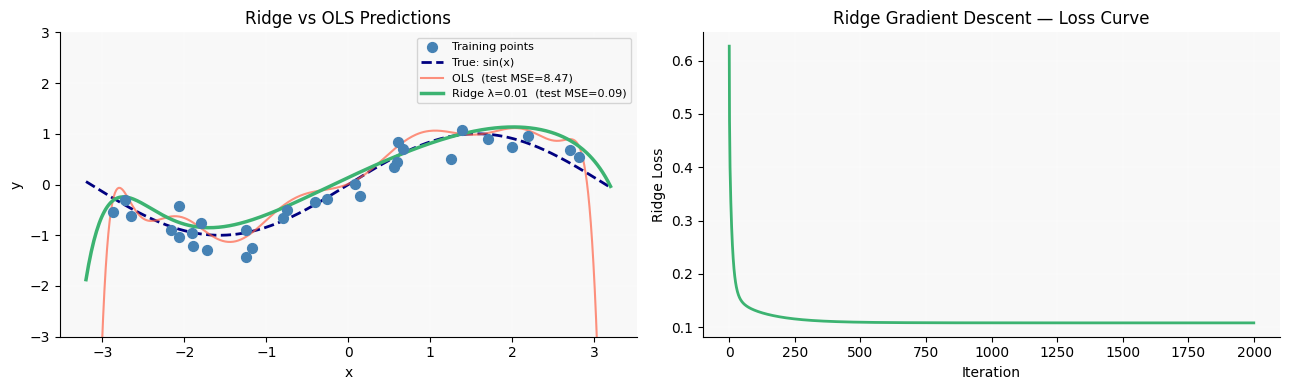

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: prediction
ax = axes[0]
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, label="Training points")
ax.plot(x_test, y_true,       color="navy",    lw=2, ls="--", label="True: sin(x)")
ax.plot(x_test, y_pred_ols,   color="tomato",  lw=1.5, alpha=0.7, label=f"OLS  (test MSE={test_mse_ols:.2f})")
ax.plot(x_test, y_pred_ridge, color="mediumseagreen", lw=2.5, label=f"Ridge λ={LAMBDA_RIDGE}  (test MSE={test_mse_ridge:.2f})")
ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Ridge vs OLS Predictions")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: training loss curve
ax = axes[1]
ax.plot(loss_history_ridge, color="mediumseagreen", lw=2)
ax.set_xlabel("Iteration"); ax.set_ylabel("Ridge Loss")
ax.set_title("Ridge Gradient Descent — Loss Curve")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5 · Lasso Regression (L1 Regularization)

### The core idea in one sentence

Lasso works just like Ridge, but swaps the squared-weight penalty for an absolute-value penalty — a small change that gives Lasso a completely different superpower: it can set weights to **exactly zero**, automatically discarding irrelevant features.

### The loss function

$$\mathcal{L}_{Lasso}(\mathbf{w}) = \frac{1}{n}\|\mathbf{y} - X\mathbf{w}\|_2^2 + \lambda\|\mathbf{w}\|_1$$

**The only change from Ridge:** $\|\mathbf{w}\|_2^2$ (sum of *squares*) → $\|\mathbf{w}\|_1$ (sum of *absolute values*):

$$\|\mathbf{w}\|_1 = |w_1| + |w_2| + \cdots + |w_p|$$

It looks like a tiny tweak, but it changes the optimizer's behavior completely.

---

### Why does L1 create zeros but L2 doesn't?

This is the most important conceptual question in this notebook. Here's the intuition without heavy math:

**The L2 penalty $w^2$ near zero is very gentle.** Its slope (derivative $2w$) approaches zero as $w \to 0$. So when a weight is already small, the penalty provides almost no extra push toward zero.

**The L1 penalty $|w|$ near zero is sharp.** Its slope (derivative $\pm\lambda$) is a constant, never getting smaller. Every weight — no matter how small — feels a constant kick toward zero.

**Analogy:** Imagine Ridge as a trampoline (gentle near the center, soft bounce) and Lasso as a cliff edge (constant pull toward the edge until you fall off). Ridge leaves weights hovering slightly above zero; Lasso pushes them off the cliff to land exactly at zero.

> **Key insight:** With L1, if a feature's signal is too weak to overcome the constant $\lambda$ push, its weight snaps to exactly zero. The feature is eliminated. With L2, every feature always contributes *something* — none are ever completely removed.

---

### Optimization: Coordinate Descent

We can't use the standard gradient approach because $|w_j|$ has no derivative at $w_j = 0$. Instead, we use **coordinate descent**: optimize one weight at a time, cycling through all of them until nothing changes.

**Step 1 — Fix all weights except $w_j$.** Compute the **partial residual** — what the error would be if weight $j$ were set to zero:

$$r_j = \mathbf{y} - \underbrace{X\mathbf{w}}_{\text{current prediction}} + \underbrace{X_j w_j}_{\text{add back } w_j\text{'s contribution}}$$

*In plain English: temporarily pretend $w_j = 0$. What error does the rest of the model make?*

**Step 2 — Find the best $w_j$ given everything else.** The subproblem is just fitting one feature to one set of residuals:

$$\min_{w_j} \frac{1}{n}\|r_j - X_j w_j\|^2 + \lambda|w_j|$$

The "unconstrained" best value (if there were no penalty) would be $\rho_j = \frac{1}{n}X_j^T r_j$ — the correlation between feature $j$ and the partial residuals.

**Step 3 — Apply the soft-threshold operator.** The exact solution to the above subproblem is:

$$\boxed{w_j^* = \mathcal{S}(\rho_j,\, \lambda) = \text{sign}(\rho_j)\cdot\max\!\left(|\rho_j| - \lambda,\; 0\right)}$$

**In plain English — three cases:**

| Situation | Result | Why |
|-----------|--------|-----|
| Feature strongly correlated with residuals: $\rho_j > \lambda$ | $w_j = \rho_j - \lambda$ | Accept the feature but shrink its weight by $\lambda$ |
| Feature strongly *negatively* correlated: $\rho_j < -\lambda$ | $w_j = \rho_j + \lambda$ | Accept with negative weight, shrunk by $\lambda$ |
| Feature weakly correlated: $|\rho_j| \leq \lambda$ | $w_j = 0$ | Not worth it — set to exactly zero |

**Analogy:** $\rho_j$ is like the "bid" that feature $j$ makes to be included. If its bid doesn't exceed the "admission price" $\lambda$, it's excluded entirely (weight = 0). If it does, it pays the $\lambda$ tax and enters at a reduced weight.

**Step 4 — Repeat** for all $j = 1, \ldots, p$, then cycle again until the weights stop changing.


In [26]:
def soft_threshold(rho, lam):
    """Soft-threshold (shrink-toward-zero) operator."""
    if rho >  lam: return rho - lam
    if rho < -lam: return rho + lam
    return 0.0

def fit_lasso_cd(X, y, lam, n_iter=2000, tol=1e-7):
    """Lasso via coordinate descent. Returns (w, loss_history)."""
    n, p = X.shape
    w = np.zeros(p)
    # Pre-compute column norms squared (for the update denominator)
    col_norms_sq = (X ** 2).mean(axis=0)   # shape (p,)
    loss_history = []

    for iteration in range(n_iter):
        w_old = w.copy()

        for j in range(p):
            # Partial residual: residual if w_j were zero
            r_j   = y - X @ w + X[:, j] * w[j]
            rho_j = (X[:, j] @ r_j) / n

            # Soft-threshold update
            denom = col_norms_sq[j]
            if denom < 1e-12:
                w[j] = 0.0
            else:
                w[j] = soft_threshold(rho_j / denom, lam / denom)

        residual = X @ w - y
        loss = (residual ** 2).mean() + lam * np.abs(w).sum()
        loss_history.append(loss)

        if np.max(np.abs(w - w_old)) < tol:
            print(f"Converged at iteration {iteration + 1}")
            break

    return w, loss_history


In [27]:
LAMBDA_LASSO = 0.01

w_lasso, loss_history_lasso = fit_lasso_cd(X_train, y_train, LAMBDA_LASSO)

y_pred_lasso = X_test @ w_lasso

train_mse_lasso = np.mean((X_train @ w_lasso - y_train) ** 2)
test_mse_lasso  = np.mean((y_pred_lasso - y_true) ** 2)

print(f"Lambda (Lasso) = {LAMBDA_LASSO}")
print(f"\nLasso weights (rounded):")
for i, wi in enumerate(w_lasso, 1):
    zero_flag = "  ← ZERO" if abs(wi) < 1e-6 else ""
    print(f"  w_{i:2d} (degree {i:2d}) = {wi:+.6f}{zero_flag}")
n_nonzero = np.sum(np.abs(w_lasso) > 1e-6)
print(f"\nNon-zero weights: {n_nonzero} / {DEGREE}")
print(f"Train MSE : {train_mse_lasso:.4f}")
print(f"Test  MSE : {test_mse_lasso:.4f}")


Converged at iteration 168
Lambda (Lasso) = 0.01

Lasso weights (rounded):
  w_ 1 (degree  1) = +1.290384
  w_ 2 (degree  2) = +0.000000  ← ZERO
  w_ 3 (degree  3) = -0.717926
  w_ 4 (degree  4) = +0.043731
  w_ 5 (degree  5) = +0.000000  ← ZERO
  w_ 6 (degree  6) = +0.000000  ← ZERO
  w_ 7 (degree  7) = +0.000000  ← ZERO
  w_ 8 (degree  8) = +0.000000  ← ZERO
  w_ 9 (degree  9) = +0.000000  ← ZERO
  w_10 (degree 10) = +0.000000  ← ZERO
  w_11 (degree 11) = +0.000000  ← ZERO
  w_12 (degree 12) = +0.000000  ← ZERO

Non-zero weights: 3 / 12
Train MSE : 0.0921
Test  MSE : 0.0478


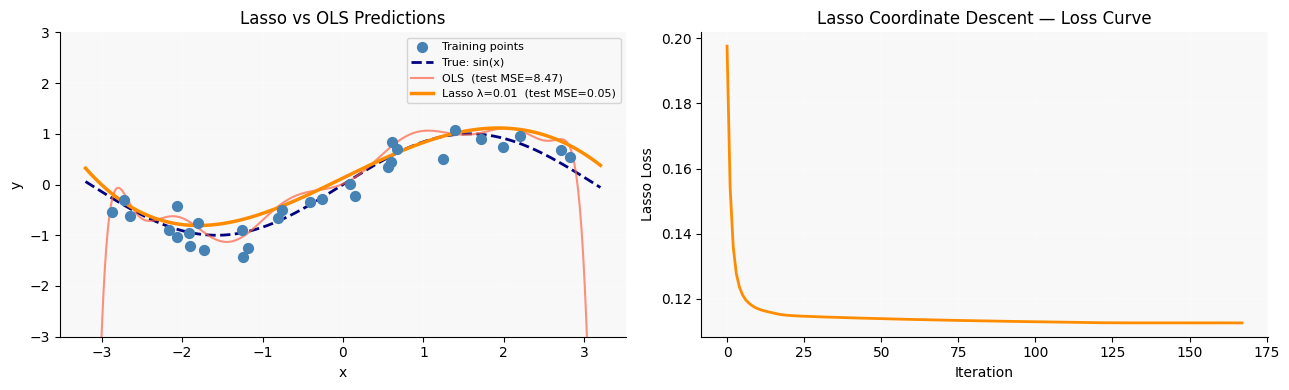

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: prediction
ax = axes[0]
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, label="Training points")
ax.plot(x_test, y_true,        color="navy",         lw=2,   ls="--", label="True: sin(x)")
ax.plot(x_test, y_pred_ols,    color="tomato",        lw=1.5, alpha=0.7, label=f"OLS  (test MSE={test_mse_ols:.2f})")
ax.plot(x_test, y_pred_lasso,  color="darkorange",    lw=2.5, label=f"Lasso λ={LAMBDA_LASSO}  (test MSE={test_mse_lasso:.2f})")
ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Lasso vs OLS Predictions")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: loss curve
ax = axes[1]
ax.plot(loss_history_lasso, color="darkorange", lw=2)
ax.set_xlabel("Iteration"); ax.set_ylabel("Lasso Loss")
ax.set_title("Lasso Coordinate Descent — Loss Curve")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 6 · Regularization Paths

### What is a regularization path?

Rather than picking one value of $\lambda$ and asking "what are the best weights?", a **regularization path** answers: "how do the weights *evolve* as $\lambda$ grows from nearly zero to very large?"

Think of it like slowly turning up a volume dial. At low $\lambda$, the model sounds like OLS (loud, possibly noisy). At high $\lambda$, everything is muted — all weights near zero.

Reading the plot:
- **Left side of the x-axis** (small $\lambda$) → close to OLS. Weights are large and free.
- **Right side** (large $\lambda$) → heavily penalized. Weights are squeezed toward zero.
- **Each colored line** represents one polynomial coefficient (degree 1 through 12).

### What to look for

- **Ridge path:** all lines drift smoothly toward zero. Every feature stays slightly "alive" even at high $\lambda$.
- **Lasso path:** lines *kink* and then hit zero at different $\lambda$ values, and once they hit zero they stay there. This is feature selection happening visually — you can literally see coefficients get eliminated one by one as $\lambda$ increases.


In [29]:
lambdas = np.logspace(-3, 1.5, 80)   # from 0.001 to ~31

ridge_coef_paths = np.zeros((len(lambdas), DEGREE))
lasso_coef_paths = np.zeros((len(lambdas), DEGREE))

for i, lam in enumerate(lambdas):
    ridge_coef_paths[i] = fit_ridge_closed(X_train, y_train, lam)
    lasso_coef_paths[i], _ = fit_lasso_cd(X_train, y_train, lam, n_iter=3000, tol=1e-7)

print("Regularization paths computed.")


Converged at iteration 900
Converged at iteration 1105
Converged at iteration 1010
Converged at iteration 634
Converged at iteration 531
Converged at iteration 342
Converged at iteration 343
Converged at iteration 342
Converged at iteration 340
Converged at iteration 339
Converged at iteration 337
Converged at iteration 335
Converged at iteration 333
Converged at iteration 321
Converged at iteration 142
Converged at iteration 147
Converged at iteration 199
Converged at iteration 1127
Converged at iteration 993
Converged at iteration 1042
Converged at iteration 1163
Converged at iteration 179
Converged at iteration 101
Converged at iteration 74
Converged at iteration 53
Converged at iteration 88
Converged at iteration 1488
Converged at iteration 222
Converged at iteration 88
Converged at iteration 64
Converged at iteration 836
Converged at iteration 92
Converged at iteration 82
Converged at iteration 101
Converged at iteration 29
Converged at iteration 2
Converged at iteration 2
Converg

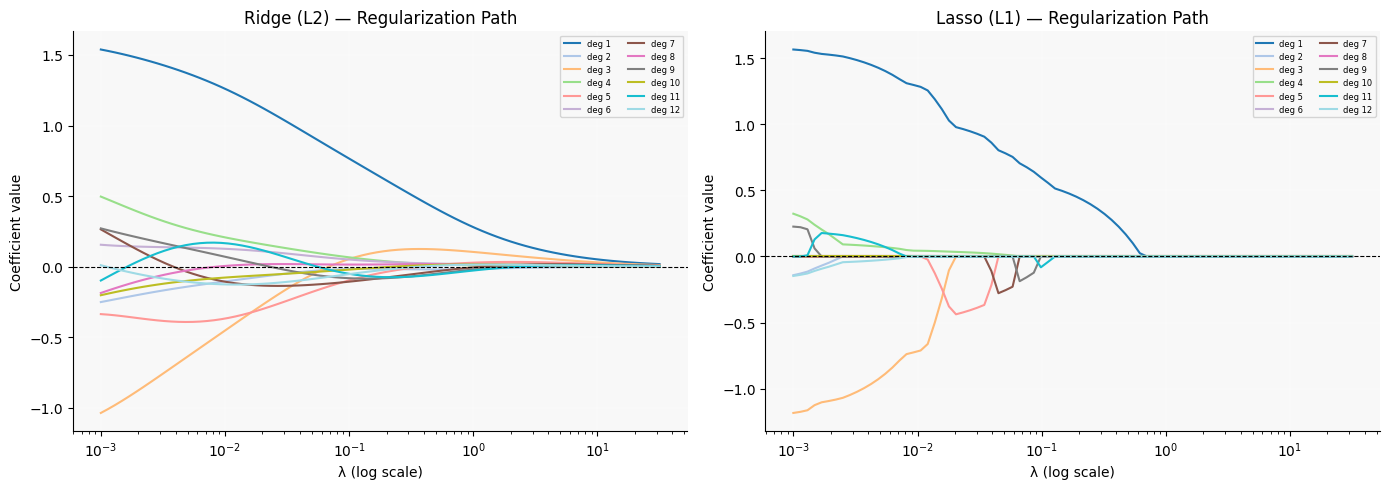

Ridge: all paths gradually approach zero.
Lasso: paths hit zero sharply at different λ — sparse solutions emerge.


In [30]:
colors = plt.cm.tab20(np.linspace(0, 1, DEGREE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(DEGREE):
    axes[0].plot(lambdas, ridge_coef_paths[:, j], color=colors[j], lw=1.5, label=f"deg {j+1}")
    axes[1].plot(lambdas, lasso_coef_paths[:, j], color=colors[j], lw=1.5, label=f"deg {j+1}")

for ax, title in zip(axes, ["Ridge (L2) — Regularization Path", "Lasso (L1) — Regularization Path"]):
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_xlabel("λ (log scale)"); ax.set_ylabel("Coefficient value")
    ax.set_title(title); ax.grid(alpha=0.3)
    ax.legend(fontsize=6, ncol=2, loc="upper right")

plt.tight_layout()
plt.show()
print("Ridge: all paths gradually approach zero.")
print("Lasso: paths hit zero sharply at different λ — sparse solutions emerge.")


---
## 7 · Interactive Exploration — Effect of λ

Drag the $\lambda$ slider to see how the regularization strength affects the fitted curve for both Ridge and Lasso simultaneously.


In [31]:
def plot_lambda_effect(log_lambda=-2.0):
    lam = 10 ** log_lambda

    w_r = fit_ridge_closed(X_train, y_train, lam)
    w_l, _ = fit_lasso_cd(X_train, y_train, lam, n_iter=3000, tol=1e-7)

    y_r = X_test @ w_r
    y_l = X_test @ w_l

    mse_r = np.mean((y_r - y_true) ** 2)
    mse_l = np.mean((y_l - y_true) ** 2)
    nz_l  = np.sum(np.abs(w_l) > 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, y_pred, color, method, mse, extra in [
        (axes[0], y_r, "mediumseagreen", "Ridge", mse_r, ""),
        (axes[1], y_l, "darkorange",     "Lasso", mse_l, f"  |  non-zero coefs: {nz_l}/{DEGREE}"),
    ]:
        ax.scatter(x_train, y_train, color="steelblue", s=40, zorder=5, label="Train data")
        ax.plot(x_test, y_true,  color="navy", lw=2, ls="--", label="True sin(x)")
        ax.plot(x_test, y_pred, color=color, lw=2.5, label=f"{method}  MSE={mse:.3f}{extra}")
        ax.set_ylim(-3, 3)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.set_title(f"{method} Regression  (λ = {lam:.4f})")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(f"λ = {lam:.4f}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

interact(
    plot_lambda_effect,
    log_lambda=FloatLogSlider(value=-2, base=10, min=-3, max=1.5, step=0.1,
                               description="log₁₀(λ)", continuous_update=False)
)


interactive(children=(FloatLogSlider(value=0.001, continuous_update=False, description='log₁₀(λ)', max=1.5, mi…

<function __main__.plot_lambda_effect(log_lambda=-2.0)>

---
## 8 · Ridge vs Lasso — Side-by-Side Comparison

### The key difference: how the penalty shapes the solution space

The best way to understand why these two methods behave differently is to think geometrically.

Both Ridge and Lasso can be rephrased as: *"find the OLS solution, but constrain the weights to stay inside a certain region."*

- **Ridge** constrains $\mathbf{w}$ to lie inside a **circle** (in 2D) or a **sphere** (in higher dimensions) — sometimes called the L2 ball.
- **Lasso** constrains $\mathbf{w}$ to lie inside a **diamond** shape — the L1 ball.

**Why the shape matters — a concrete analogy:**

Imagine the OLS solution (unconstrained best weights) sits at some point in space. Regularization says "you can't go there — stay inside the allowed region." The constrained solution is where the OLS loss contours first *touch* the allowed region.

- The **circle** has no corners. When an oval-shaped loss contour touches a circle, it almost always lands on the smooth surface — not on an axis. So no weight becomes exactly zero.
- The **diamond** has sharp corners that sit on the axes (where $w_1 = 0$ or $w_2 = 0$). Loss contours are much more likely to first touch the diamond at a corner. When they do, one or more weights snap to exactly zero.

> **Key insight:** It's the *pointy corners* of the L1 ball that create sparsity. The smooth L2 ball has no corners to get "snagged on," so Ridge weights just shrink uniformly.

---

### Summary comparison

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|-----------|
| Penalty | Sum of squared weights: $\lambda(w_1^2 + w_2^2 + \cdots)$ | Sum of absolute weights: $\lambda(\|w_1\| + \|w_2\| + \cdots)$ |
| Constraint shape | Circle / sphere | Diamond / cross |
| Can weights reach exactly zero? | No — only asymptotically approach zero | Yes — snaps to exactly zero |
| Automatic feature selection? | No | Yes |
| Works well when... | All features are somewhat useful | Only a few features truly matter |
| Handles correlated features | Distributes weight among them | Picks one, ignores the rest |
| Has a closed-form solution? | Yes — always | No — needs iterative optimization |


Converged at iteration 98


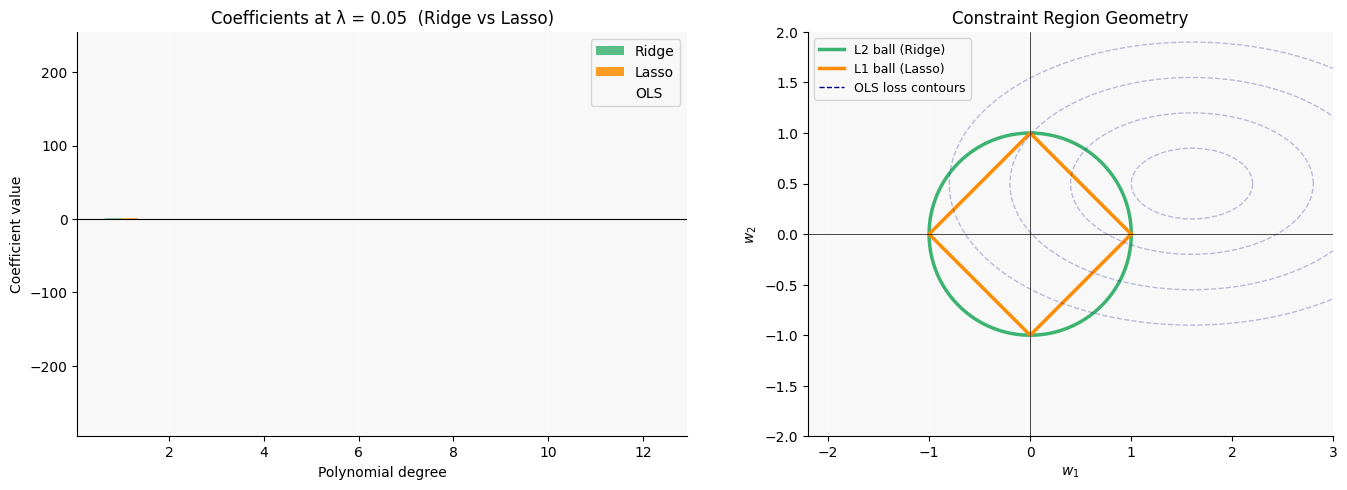

Ridge non-zero weights: 12 / 12
Lasso non-zero weights: 3 / 12


In [32]:
LAM_COMPARE = 0.05

w_ridge_c = fit_ridge_closed(X_train, y_train, LAM_COMPARE)
w_lasso_c, _ = fit_lasso_cd(X_train, y_train, LAM_COMPARE, n_iter=3000)

degrees = np.arange(1, DEGREE + 1)
bar_w   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
ax.bar(degrees - bar_w/2, w_ridge_c, bar_w, color="mediumseagreen", label="Ridge", alpha=0.85)
ax.bar(degrees + bar_w/2, w_lasso_c, bar_w, color="darkorange",     label="Lasso", alpha=0.85)
ax.bar(degrees - bar_w/2, w_ols,     bar_w * 0, color="tomato",     label="OLS",   alpha=0)  # invisible, just for legend
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Polynomial degree"); ax.set_ylabel("Coefficient value")
ax.set_title(f"Coefficients at λ = {LAM_COMPARE}  (Ridge vs Lasso)")
ax.legend(); ax.grid(alpha=0.3)

# Geometric intuition: L1 vs L2 ball
ax = axes[1]
theta = np.linspace(0, 2 * np.pi, 400)
# L2 ball (circle)
ax.plot(np.cos(theta), np.sin(theta), color="mediumseagreen", lw=2.5, label="L2 ball (Ridge)")
# L1 ball (diamond)
diamond = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
ax.plot(diamond[:,0], diamond[:,1], color="darkorange", lw=2.5, label="L1 ball (Lasso)")
# Elliptical OLS contours
for r in [0.5, 1.0, 1.5, 2.0]:
    ax.plot(r * 1.2 * np.cos(theta) + 1.6,
            r * 0.7 * np.sin(theta) + 0.5,
            color="navy", alpha=0.25, lw=1, ls="--")
ax.plot([], [], color="navy", ls="--", lw=1, label="OLS loss contours")
ax.set_aspect("equal")
ax.set_xlim(-2.2, 3.0); ax.set_ylim(-2.0, 2.0)
ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("$w_1$"); ax.set_ylabel("$w_2$")
ax.set_title("Constraint Region Geometry")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ridge non-zero weights: {np.sum(np.abs(w_ridge_c) > 1e-6)} / {DEGREE}")
print(f"Lasso non-zero weights: {np.sum(np.abs(w_lasso_c) > 1e-6)} / {DEGREE}")


Converged at iteration 900
Converged at iteration 1329
Converged at iteration 998
Converged at iteration 547
Converged at iteration 609
Converged at iteration 343
Converged at iteration 341
Converged at iteration 339
Converged at iteration 337
Converged at iteration 334
Converged at iteration 326
Converged at iteration 143
Converged at iteration 161
Converged at iteration 658
Converged at iteration 968
Converged at iteration 1107
Converged at iteration 231
Converged at iteration 97
Converged at iteration 67
Converged at iteration 75
Converged at iteration 1563
Converged at iteration 129
Converged at iteration 60
Converged at iteration 368
Converged at iteration 63
Converged at iteration 145
Converged at iteration 24
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 1
Converged at iteration 1

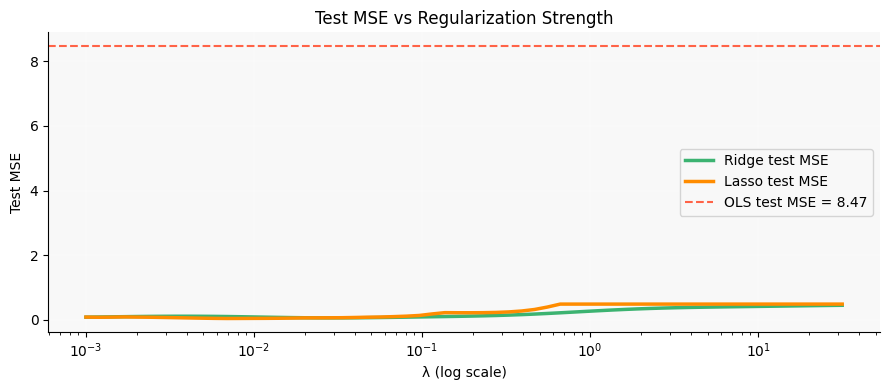

Best λ (Ridge): 0.0281  →  test MSE = 0.0634
Best λ (Lasso): 0.0069  →  test MSE = 0.0444


In [33]:
# Sweep lambda and record test MSE for Ridge and Lasso
lambdas_eval = np.logspace(-3, 1.5, 60)
ridge_test_mse = []
lasso_test_mse = []

for lam in lambdas_eval:
    wr = fit_ridge_closed(X_train, y_train, lam)
    wl, _ = fit_lasso_cd(X_train, y_train, lam, n_iter=2000, tol=1e-7)
    ridge_test_mse.append(np.mean((X_test @ wr - y_true) ** 2))
    lasso_test_mse.append(np.mean((X_test @ wl - y_true) ** 2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lambdas_eval, ridge_test_mse, color="mediumseagreen", lw=2.5, label="Ridge test MSE")
ax.plot(lambdas_eval, lasso_test_mse, color="darkorange",     lw=2.5, label="Lasso test MSE")
ax.axhline(test_mse_ols, color="tomato", lw=1.5, ls="--", label=f"OLS test MSE = {test_mse_ols:.2f}")
ax.set_xscale("log")
ax.set_xlabel("λ (log scale)"); ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Regularization Strength")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_ridge_lam = lambdas_eval[np.argmin(ridge_test_mse)]
best_lasso_lam = lambdas_eval[np.argmin(lasso_test_mse)]
print(f"Best λ (Ridge): {best_ridge_lam:.4f}  →  test MSE = {min(ridge_test_mse):.4f}")
print(f"Best λ (Lasso): {best_lasso_lam:.4f}  →  test MSE = {min(lasso_test_mse):.4f}")


---
## 9 · Summary

| Concept | Key Idea |
|---------|----------|
| **Overfitting** | Model fits training noise; poor generalization to new data |
| **Regularization** | Adds a weight-magnitude penalty to the loss to constrain model complexity |
| **Ridge (L2)** | Penalty $\lambda\|\mathbf{w}\|_2^2$; all weights shrink but stay non-zero |
| **Ridge closed form** | $(X^TX + \lambda n I)^{-1}X^T\mathbf{y}$ — always invertible, always unique |
| **Lasso (L1)** | Penalty $\lambda\|\mathbf{w}\|_1$; weights can be exactly zero (feature selection) |
| **Soft threshold** | $\mathcal{S}(\rho, \lambda) = \text{sign}(\rho)\max(|\rho|-\lambda,0)$ — the Lasso update per coordinate |
| **Coordinate descent** | Lasso optimization: minimize over one weight at a time, cycling until convergence |
| **Regularization path** | How coefficients change as $\lambda$ sweeps from 0 to $\infty$ |
| **λ too small** | Underfitting (OLS-like behavior, may overfit) |
| **λ too large** | Underfitting (all weights pushed to zero) |
| **L2 ball geometry** | Smooth sphere → optimal point rarely on an axis → no sparsity |
| **L1 ball geometry** | Diamond with corners on axes → optimal point often at a corner → sparsity |
| **Ridge prior** | Equivalent to Gaussian prior $\mathbf{w} \sim \mathcal{N}(0, \frac{1}{2\lambda}I)$ |
| **Lasso prior** | Equivalent to Laplace prior $\mathbf{w} \sim \text{Laplace}(0, \frac{1}{\lambda})$ — heavy tails encourage zeros |
| **Use Ridge when** | All features are likely relevant, correlated features present |
| **Use Lasso when** | Many irrelevant features expected, sparse solution desired |
